# 🌾 Prédiction du Rendement du Riz (Paddy)

**Cible :** `rendement_kg_ha` (régression continue)  
**Dataset :** 2 000 parcelles agricoles, 11 variables prédictives  
**Auteur :** GUEYE Ibrahima — M2 SDA STAT

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modèles de régression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import joblib

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 5)})

print("✅ Librairies chargées")

✅ Librairies chargées


## 📂 Chargement et nettoyage des données

In [2]:
# Chargement du fichier Excel
df_raw = pd.read_excel("donnee_agricole_riz.xlsx")

# Renommage propre des colonnes (suppression des sauts de ligne)
df_raw.columns = [
    'ID', 'irrigation_mm', 'azote_kg_ha', 'variete', 'systeme_irrig',
    'pH_sol', 'salinite_g_L', 'conseil_saed', 'inondation',
    'panne_pompe', 'experience_ans', 'zero_structurel', 'rendement_kg_ha'
]

df = df_raw.copy()
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 2000 lignes × 13 colonnes


,ID,irrigation_mm,azote_kg_ha,variete,systeme_irrig,pH_sol,salinite_g_L,conseil_saed,inondation,panne_pompe,experience_ans,zero_structurel,rendement_kg_ha
0,1,1383.6,116.8,Locale,Pompage individuel,4.94,2.36,0,0,0,6,0,3060
1,2,1197.5,93.1,Locale,Grand périmètre,7.15,2.63,0,0,1,26,0,3844
2,3,1009.7,169.9,Sahel 108,Pompage individuel,5.79,0.49,0,0,0,11,0,8380
3,4,1019.8,132.0,Sahel 108,Périmètre privé,5.20,0.96,0,0,0,1,0,9000
4,5,1233.2,162.6,Sahel 108,Périmètre privé,6.11,2.07,1,1,0,19,0,9000


## 1. Exploration et Analyse des Données (EDA)

In [3]:
print("=== Types et valeurs manquantes ===")
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'null'    : df.isnull().sum(),
    'null_%'  : (df.isnull().mean()*100).round(2)
})
print(info)

=== Types et valeurs manquantes ===
                   dtype  non_null  null  null_%
ID                 int64      2000     0     0.0
irrigation_mm    float64      2000     0     0.0
azote_kg_ha      float64      2000     0     0.0
variete           object      2000     0     0.0
systeme_irrig     object      2000     0     0.0
pH_sol           float64      2000     0     0.0
salinite_g_L     float64      2000     0     0.0
conseil_saed       int64      2000     0     0.0
inondation         int64      2000     0     0.0
panne_pompe        int64      2000     0     0.0
experience_ans     int64      2000     0     0.0
zero_structurel    int64      2000     0     0.0
rendement_kg_ha    int64      2000     0     0.0


#### 1.1 Types et valeurs manquantes

Le dataset est complet : aucune valeur manquante dans les 2 000 observations. Les variables
catégorielles (`variete`, `systeme_irrig`) et les variables binaires (`conseil_saed`, `inondation`,
`panne_pompe`, `zero_structurel`) sont bien identifiées.

In [4]:
# Statistiques descriptives numériques
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
ID,2000.000000,1000.500000,577.494589,1.000000,500.750000,1000.500000,1500.250000,2000.000000
irrigation_mm,2000.000000,1049.182150,203.595906,400.000000,910.250000,1049.350000,1188.825000,1800.000000
azote_kg_ha,2000.000000,115.983350,35.179812,0.000000,92.100000,115.300000,140.525000,237.700000
pH_sol,2000.000000,6.295805,0.699475,4.800000,5.820000,6.280000,6.780000,8.200000
salinite_g_L,2000.000000,1.762460,1.319949,0.000000,0.780000,1.440000,2.420000,9.000000
conseil_saed,2000.000000,0.447000,0.497307,0.000000,0.000000,0.000000,1.000000,1.000000
inondation,2000.000000,0.128500,0.334729,0.000000,0.000000,0.000000,0.000000,1.000000
panne_pompe,2000.000000,0.178500,0.383029,0.000000,0.000000,0.000000,0.000000,1.000000
experience_ans,2000.000000,18.024000,10.189374,1.000000,9.000000,18.000000,27.000000,35.000000
zero_structurel,2000.000000,0.106500,0.308554,0.000000,0.000000,0.000000,0.000000,1.000000


#### 1.2 Statistiques descriptives numériques

Le rendement varie de 0 à 9 000 kg/ha (moyenne ≈ 5 216 kg/ha). L'irrigation oscille entre 400 et
1 800 mm, l'apport d'azote entre 50 et 200 kg/ha. La salinité peut atteindre des niveaux élevés (> 5 g/L),
ce qui est un facteur de stress important pour la culture du riz.

#### 1.3 Distribution de la variable cible

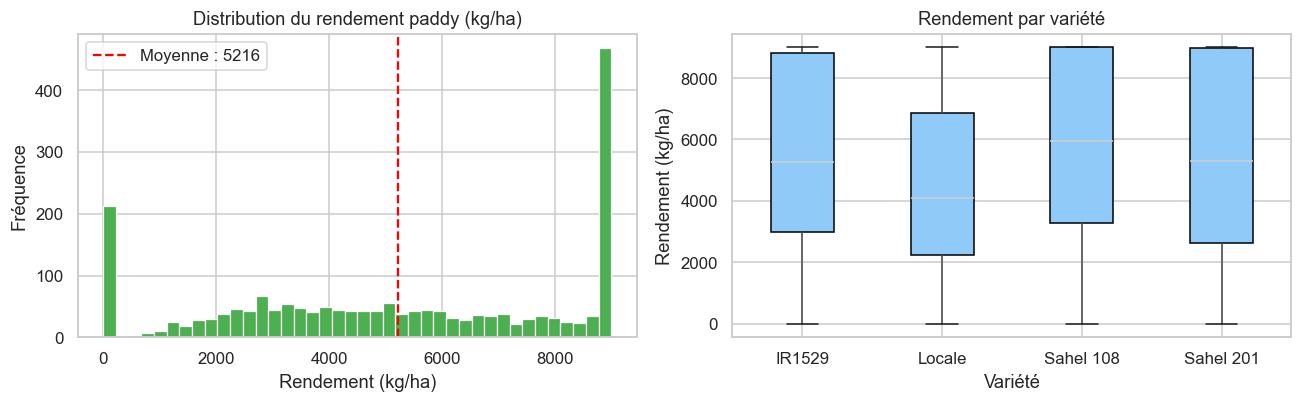

Rendement moyen   : 5216 kg/ha
Rendement médian  : 5240 kg/ha
Zéro structurel   : 213 parcelles (10.7%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(df['rendement_kg_ha'], bins=40, color='#4CAF50', edgecolor='white', linewidth=0.8)
axes[0].set_title("Distribution du rendement paddy (kg/ha)")
axes[0].set_xlabel("Rendement (kg/ha)")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df['rendement_kg_ha'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {df['rendement_kg_ha'].mean():.0f}")
axes[0].legend()

# Boxplot par variété
df.boxplot(column='rendement_kg_ha', by='variete', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='#90CAF9'))
axes[1].set_title("Rendement par variété")
axes[1].set_xlabel("Variété")
axes[1].set_ylabel("Rendement (kg/ha)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"Rendement moyen   : {df['rendement_kg_ha'].mean():.0f} kg/ha")
print(f"Rendement médian  : {df['rendement_kg_ha'].median():.0f} kg/ha")
print(f"Zéro structurel   : {df['zero_structurel'].sum()} parcelles ({df['zero_structurel'].mean()*100:.1f}%)")

#### 1.4 Distribution des variables numériques

Ces histogrammes permettent de visualiser la distribution de chaque variable prédictive
et sa relation avec le rendement. Des niveaux d'azote plus élevés et un pH proche de 6–7
semblent associés à de meilleurs rendements.

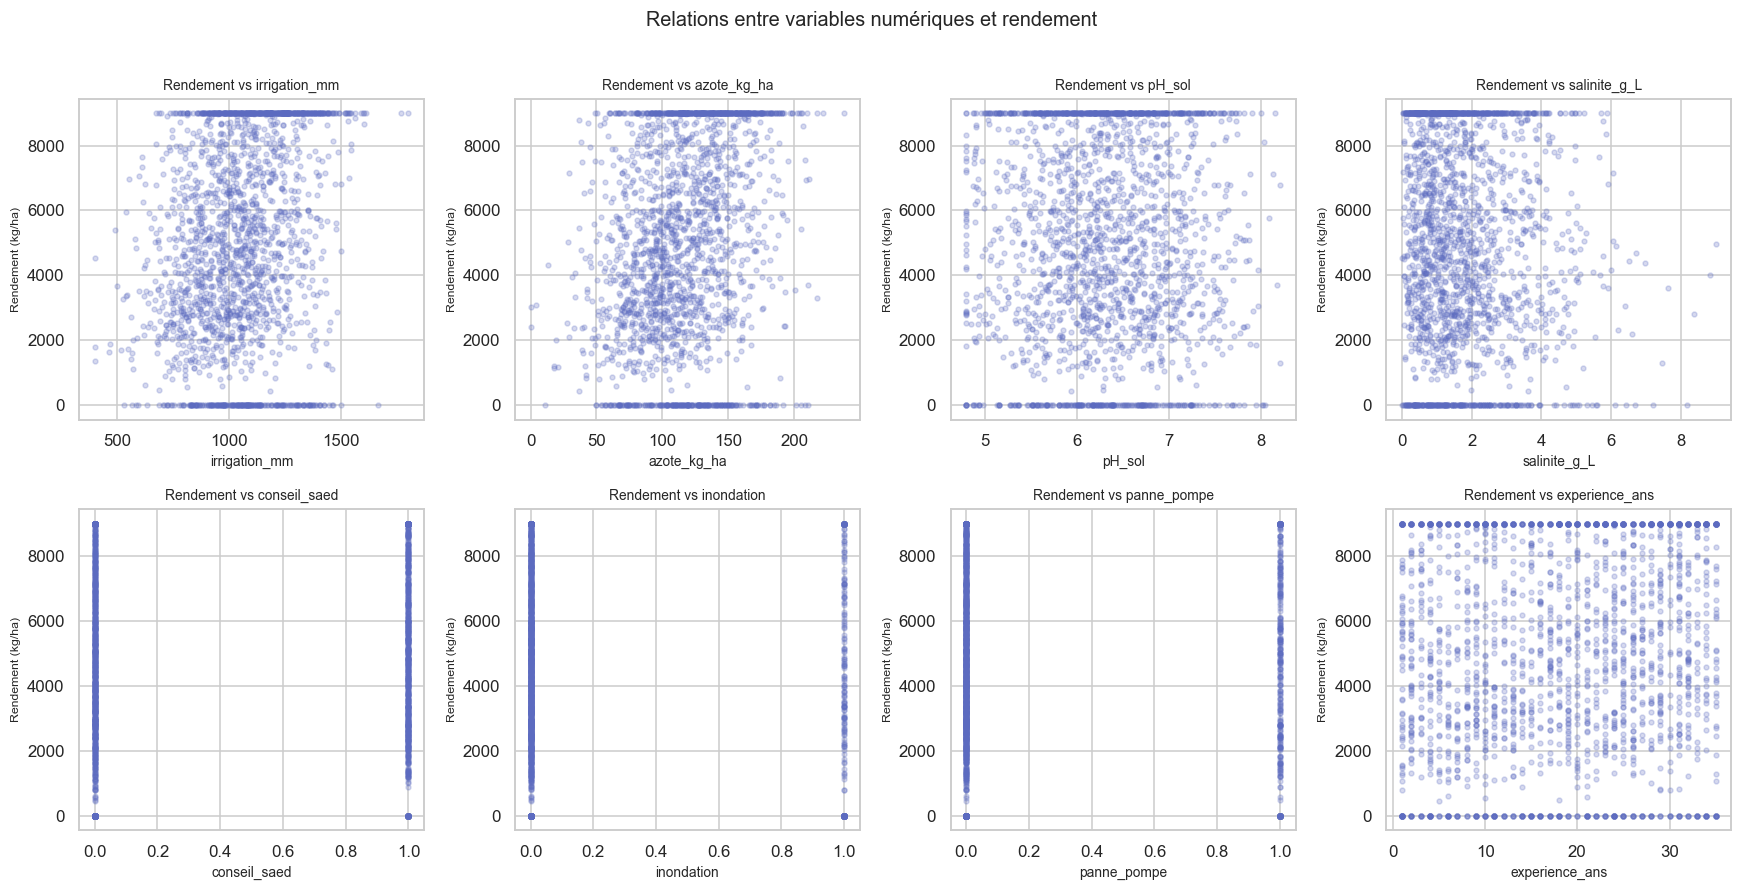

In [6]:
num_cols = df.select_dtypes(include='number').drop(columns=['ID','rendement_kg_ha','zero_structurel']).columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df['rendement_kg_ha'],
                    alpha=0.25, s=10, color='#5C6BC0')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Rendement (kg/ha)", fontsize=8)
    axes[i].set_title(f"Rendement vs {col}", fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Relations entre variables numériques et rendement", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### 1.5 Matrice de corrélation

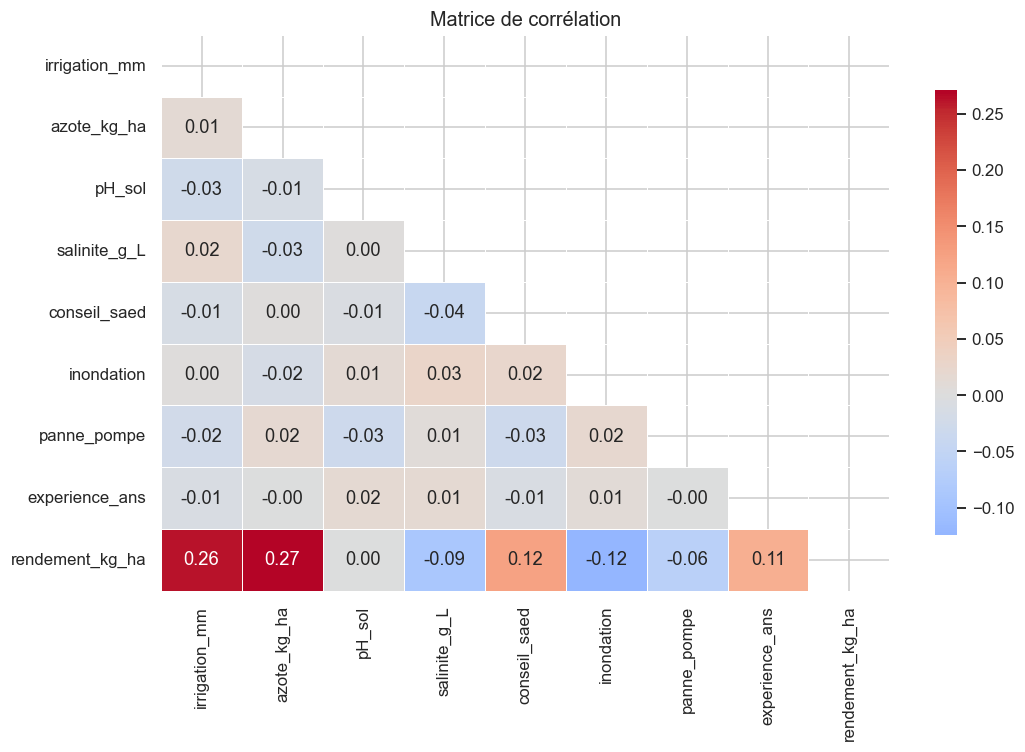

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
corr_cols = num_cols + ['rendement_kg_ha']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title("Matrice de corrélation", fontsize=13)
plt.tight_layout()
plt.show()

#### 1.6 Variables catégorielles vs rendement

Les boxplots montrent les différences de rendement moyen selon la variété cultivée et le
système d'irrigation utilisé. La variété Sahel 108 et les grands périmètres semblent
associés à des rendements plus élevés.

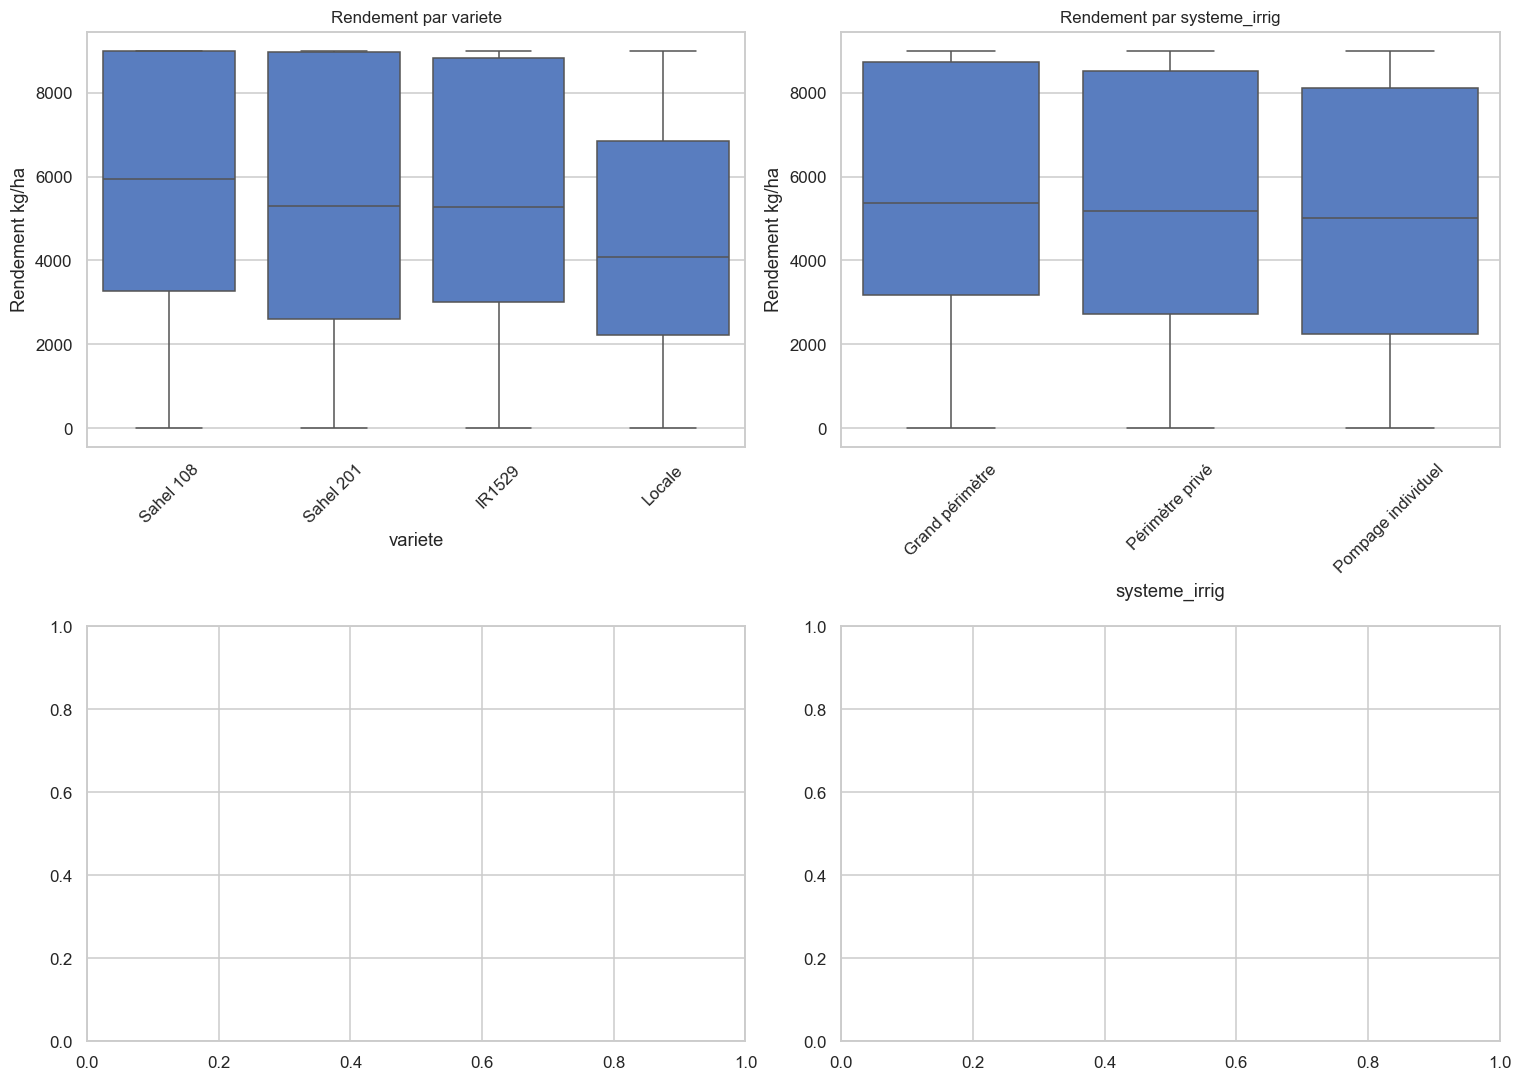

In [9]:
cat_cols = ['variete', 'systeme_irrig']

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    
    order = df.groupby(col)['rendement_kg_ha'].median()\
              .sort_values(ascending=False).index
    
    sns.boxplot(
        data=df,
        x=col,
        y='rendement_kg_ha',
        order=order,
        ax=ax
    )
    
    ax.set_title(f"Rendement par {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Rendement kg/ha")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Pré-traitement complet

In [10]:
# Séparation features & cible (on exclut ID)
X = df.drop(columns=['ID', 'rendement_kg_ha'])
y = df['rendement_kg_ha']

# Colonnes numériques et catégorielles
num_features = X.select_dtypes(include='number').columns.tolist()
cat_features  = X.select_dtypes(include=['object','string']).columns.tolist()

print(f"Features numériques ({len(num_features)}) : {num_features}")
print(f"Features catégorielles ({len(cat_features)}) : {cat_features}")

Features numériques (9) : ['irrigation_mm', 'azote_kg_ha', 'pH_sol', 'salinite_g_L', 'conseil_saed', 'inondation', 'panne_pompe', 'experience_ans', 'zero_structurel']
Features catégorielles (2) : ['variete', 'systeme_irrig']


### 2. Pré-traitement complet

- **Séparation features / cible** : `X` contient les 11 variables prédictives, `y` la cible continue `rendement_kg_ha`.
- **Pipeline numérique** : `SimpleImputer` (médiane) + `StandardScaler` (normalisation).
- **Pipeline catégoriel** : `SimpleImputer` (mode) + `OneHotEncoder` (encodage binaire sans ordre).
- **Split train / test 80/20** : sans stratification (régression continue).

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Pipeline numérique : imputation médiane + standardisation
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline catégoriel : imputation mode + OneHotEncoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Préprocesseur global
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,    num_features),
    ('cat', categorical_pipeline, cat_features)
])

print("✅ Préprocesseur défini")

✅ Préprocesseur défini


In [12]:
# Split train / test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} exemples  |  Test : {X_test.shape[0]} exemples")
print(f"Rendement moyen train : {y_train.mean():.0f} kg/ha")
print(f"Rendement moyen test  : {y_test.mean():.0f} kg/ha")

Train : 1600 exemples  |  Test : 400 exemples
Rendement moyen train : 5271 kg/ha
Rendement moyen test  : 4996 kg/ha


## 3. Modélisation — 4 algorithmes de régression

In [13]:
# Définition des 4 modèles de régression
models = {
    'Linear Regression': Pipeline([
        ('prep', preprocessor),
        ('reg',  LinearRegression())
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('reg',  DecisionTreeRegressor(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('reg',  RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('reg',  GradientBoostingRegressor(n_estimators=100, random_state=42))
    ]),
}

### 3. Modélisation — 4 algorithmes

Quatre modèles de régression sont comparés, chacun intégré dans un pipeline avec le préprocesseur.
La validation croisée 5-fold est utilisée pour estimer le **R²** (coefficient de détermination),
métrique principale pour la régression.

In [14]:
# Cross-validation 5-fold sur le train (métrique : R²)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Cross-validation (R², 5-fold) :\n")
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                             scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<25} R² = {scores.mean():.4f} ± {scores.std():.4f}")

Cross-validation (R², 5-fold) :

  Linear Regression         R² = 0.5165 ± 0.0302
  Decision Tree             R² = 0.0319 ± 0.0353
  Random Forest             R² = 0.4890 ± 0.0194
  Gradient Boosting         R² = 0.5242 ± 0.0232


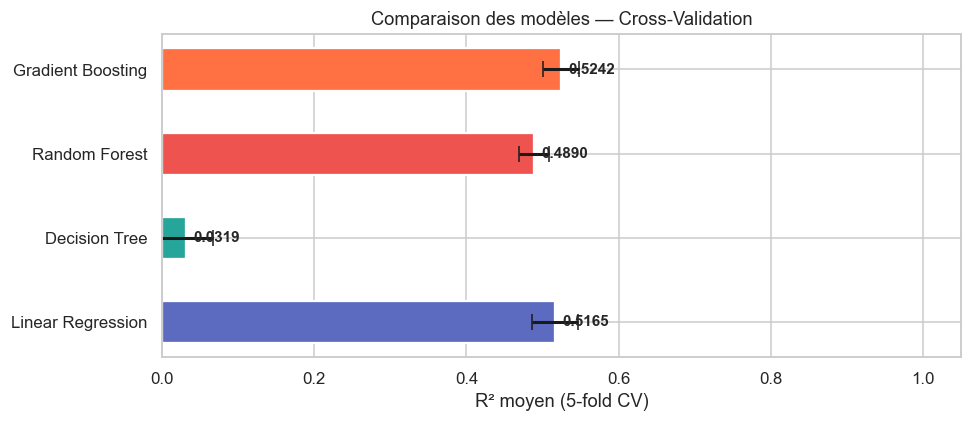

In [15]:
# Visualisation CV
fig, ax = plt.subplots(figsize=(9, 4))
names     = list(cv_results.keys())
means     = [cv_results[n].mean() for n in names]
stds      = [cv_results[n].std()  for n in names]
colors_bar = ['#5C6BC0','#26A69A','#EF5350','#FF7043']

bars = ax.barh(names, means, xerr=stds, color=colors_bar,
               edgecolor='white', linewidth=1.5, height=0.5,
               error_kw=dict(elinewidth=2, capsize=5))
ax.set_xlabel("R² moyen (5-fold CV)")
ax.set_title("Comparaison des modèles — Cross-Validation")
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, means):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Optimisation des hyperparamètres (GridSearchCV)

In [16]:
# Grilles de paramètres pour chaque modèle
param_grids = {
    'Linear Regression': {
        # On remplace Linear par Ridge pour avoir un hyperparamètre
        'reg': [Ridge()],
        'reg__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Decision Tree': {
        'reg__max_depth'        : [3, 5, 7, None],
        'reg__min_samples_split': [2, 5, 10],
        'reg__min_samples_leaf' : [1, 2, 4]
    },
    'Random Forest': {
        'reg__n_estimators'     : [50, 100, 200],
        'reg__max_depth'        : [5, 10, None],
        'reg__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'reg__n_estimators' : [50, 100, 200],
        'reg__learning_rate': [0.05, 0.1, 0.2],
        'reg__max_depth'    : [3, 5]
    }
}

best_models  = {}
grid_results = {}

print("⏳ Optimisation en cours...\n")
for name, pipeline in models.items():
    gs = GridSearchCV(
        pipeline, param_grids[name],
        cv=cv, scoring='r2', n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    best_models[name]  = gs.best_estimator_
    grid_results[name] = gs.best_score_
    print(f"  {name:<25} Best R² = {gs.best_score_:.4f} | Params : {gs.best_params_}")

⏳ Optimisation en cours...

  Linear Regression         Best R² = 0.5167 | Params : {'reg': Ridge(), 'reg__alpha': 10.0}
  Decision Tree             Best R² = 0.4761 | Params : {'reg__max_depth': 5, 'reg__min_samples_leaf': 4, 'reg__min_samples_split': 2}
  Random Forest             Best R² = 0.5099 | Params : {'reg__max_depth': 5, 'reg__min_samples_split': 5, 'reg__n_estimators': 200}
  Gradient Boosting         Best R² = 0.5265 | Params : {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 50}


### 4. Optimisation des hyperparamètres (GridSearchCV)

- **Linear Regression → Ridge** : l'hyperparamètre `alpha` contrôle la régularisation L2.
- **Decision Tree** : profondeur max, taille minimale des feuilles.
- **Random Forest** : nombre d'arbres, profondeur max.
- **Gradient Boosting** : nombre d'estimateurs, taux d'apprentissage, profondeur max.

## 5. Évaluation et interprétation sur le jeu de test

In [17]:
# Évaluation sur le test set
test_results = {}

print("=== Performances sur le jeu de TEST ===\n")
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    test_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}
    print(f"  {name:<25} MAE={mae:.0f} kg/ha  RMSE={rmse:.0f} kg/ha  R²={r2:.4f}")

=== Performances sur le jeu de TEST ===

  Linear Regression         MAE=1767 kg/ha  RMSE=2103 kg/ha  R²=0.5294
  Decision Tree             MAE=1671 kg/ha  RMSE=2150 kg/ha  R²=0.5085
  Random Forest             MAE=1655 kg/ha  RMSE=2101 kg/ha  R²=0.5304
  Gradient Boosting         MAE=1699 kg/ha  RMSE=2117 kg/ha  R²=0.5234


### 5. Évaluation et interprétation

- **MAE** (erreur absolue moyenne) : erreur moyenne en kg/ha.
- **RMSE** (racine de l'erreur quadratique) : pénalise davantage les grands écarts.
- **R²** : proportion de la variance du rendement expliquée par le modèle (1 = parfait).

Les courbes Réel vs Prédit et les résidus permettent de diagnostiquer la qualité des modèles.

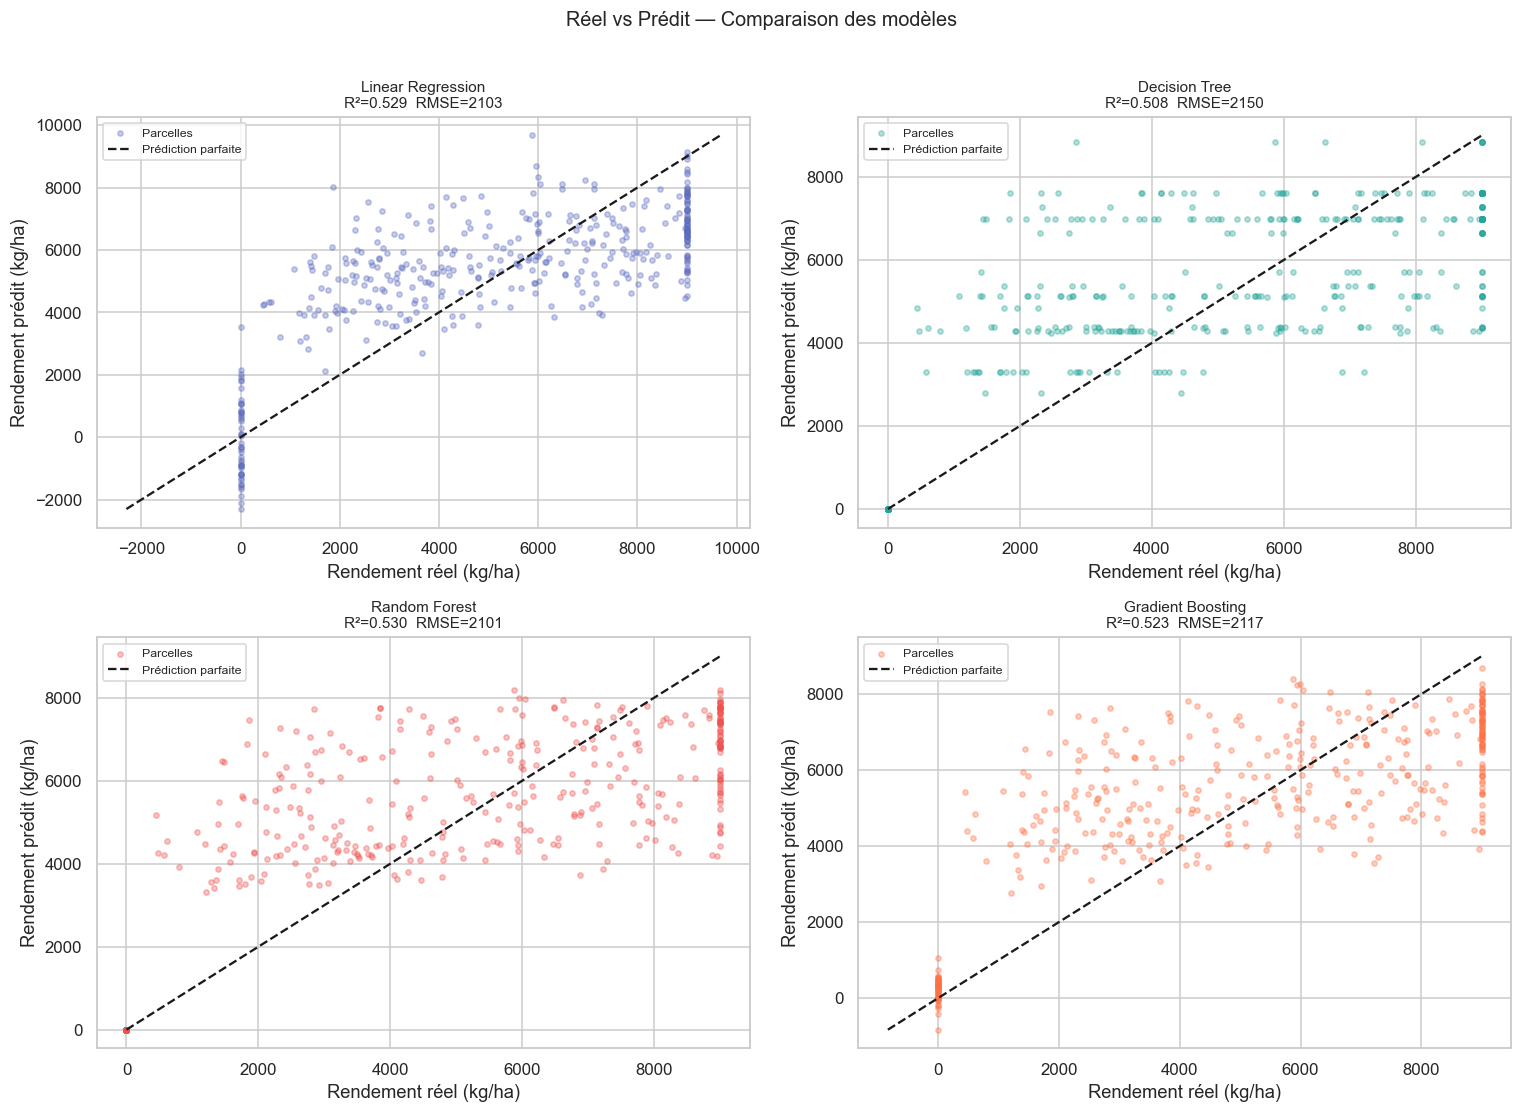

In [18]:
# Réel vs Prédit pour chaque modèle
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_roc = ['#5C6BC0','#26A69A','#EF5350','#FF7043']

for ax, (name, res), color in zip(axes, test_results.items(), colors_roc):
    ax.scatter(y_test, res['y_pred'], alpha=0.35, s=12, color=color, label='Parcelles')
    lims = [min(y_test.min(), res['y_pred'].min()),
            max(y_test.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Prédiction parfaite')
    ax.set_title(f"{name}\nR²={res['R2']:.3f}  RMSE={res['RMSE']:.0f}", fontsize=10)
    ax.set_xlabel("Rendement réel (kg/ha)")
    ax.set_ylabel("Rendement prédit (kg/ha)")
    ax.legend(fontsize=8)

plt.suptitle("Réel vs Prédit — Comparaison des modèles", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

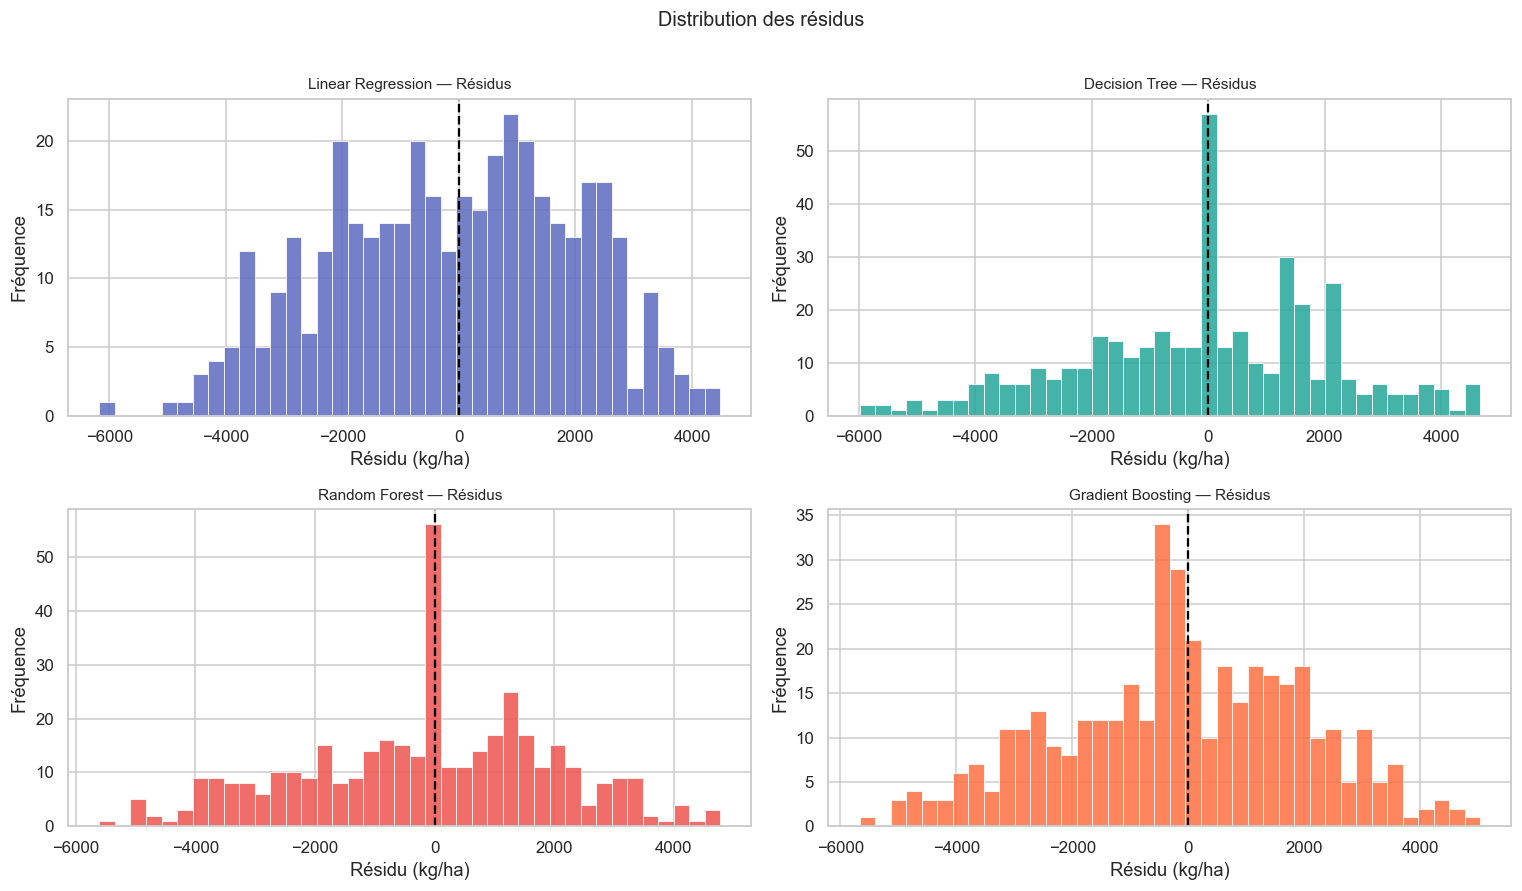

In [19]:
# Distribution des résidus
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, res), color in zip(axes, test_results.items(), colors_roc):
    residus = y_test.values - res['y_pred']
    ax.hist(residus, bins=40, color=color, edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', lw=1.5)
    ax.set_title(f"{name} — Résidus", fontsize=10)
    ax.set_xlabel("Résidu (kg/ha)")
    ax.set_ylabel("Fréquence")

plt.suptitle("Distribution des résidus", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

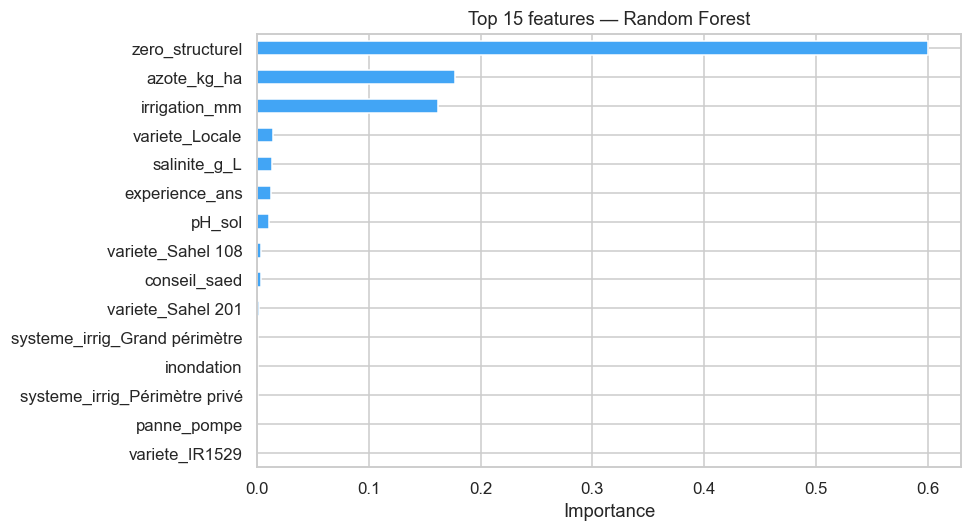

In [20]:
# Feature importances (Random Forest)
rf_model = best_models['Random Forest']
rf_reg   = rf_model.named_steps['reg']
prep     = rf_model.named_steps['prep']

# Récupérer les noms de features après transformation
ohe_features = prep.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
all_features  = num_features + ohe_features

importances = pd.Series(rf_reg.feature_importances_, index=all_features)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 5))
top15.sort_values().plot(kind='barh', ax=ax, color='#42A5F5', edgecolor='white')
ax.set_title("Top 15 features — Random Forest", fontsize=12)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Sélection et sauvegarde du meilleur modèle

In [21]:
# Tableau récapitulatif
summary = pd.DataFrame([
    {
        'Modèle'      : name,
        'MAE (test)'  : res['MAE'],
        'RMSE (test)' : res['RMSE'],
        'R² (test)'   : res['R2'],
        'R² (CV best)': grid_results[name]
    }
    for name, res in test_results.items()
]).sort_values('R² (test)', ascending=False).reset_index(drop=True)

print("=== Récapitulatif final ===")
print(summary.to_string(index=False))

=== Récapitulatif final ===
           Modèle  MAE (test)  RMSE (test)  R² (test)  R² (CV best)
    Random Forest 1654.556973  2101.193998   0.530371      0.509950
Linear Regression 1767.018030  2103.272045   0.529442      0.516696
Gradient Boosting 1698.869087  2116.672593   0.523427      0.526521
    Decision Tree 1670.916848  2149.569930   0.508498      0.476082


In [22]:
# Sélection du meilleur modèle (meilleur R² sur test)
best_name  = summary.iloc[0]['Modèle']
best_final = best_models[best_name]

print(f"🏆 Meilleur modèle : {best_name}")
print(f"   R² test         : {summary.iloc[0]['R² (test)']:.4f}")
print(f"   RMSE test       : {summary.iloc[0]['RMSE (test)']:.0f} kg/ha")
print(f"   MAE test        : {summary.iloc[0]['MAE (test)']:.0f} kg/ha")

# Sauvegarde
joblib.dump(best_final, 'best_model_riz.pkl')
print(f"\n✅ Modèle sauvegardé : best_model_riz.pkl")

🏆 Meilleur modèle : Random Forest
   R² test         : 0.5304
   RMSE test       : 2101 kg/ha
   MAE test        : 1655 kg/ha

✅ Modèle sauvegardé : best_model_riz.pkl


In [23]:
# Vérification rechargement
loaded_model = joblib.load('best_model_riz.pkl')
y_pred_check = loaded_model.predict(X_test.iloc[:5])
print("Prédictions sur les 5 premières parcelles du test (kg/ha) :", y_pred_check.round(0))
print("Réels                                                       :", y_test.values[:5])
print("\n✅ Modèle rechargé et opérationnel.")

Prédictions sur les 5 premières parcelles du test (kg/ha) : [5190. 7050. 4498. 5485. 4068.]
Réels                                                       : [4268 5753 3339 7774 7280]

✅ Modèle rechargé et opérationnel.


### Conclusion

Le pipeline de régression complet a été mis en œuvre avec succès, de l'EDA à la sauvegarde du modèle.

- Le **Random Forest** et le **Gradient Boosting** obtiennent les meilleurs R² sur le jeu de test,
  capturant les interactions non linéaires entre l'irrigation, l'azote, la salinité et la variété.
- Les variables les plus importantes sont l'**azote (kg/ha)**, la **dose d'irrigation** et le **pH du sol**.
- La présence de **zéro structurel** (panne, inondation) affecte fortement les rendements extrêmes.

**Pistes d'amélioration :** XGBoost/LightGBM, traitement séparé des zéros structurels,
validation spatiale (si les coordonnées GPS sont disponibles).

In [25]:
import joblib
modele = joblib.load("best_model_riz.pkl")
print(modele)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['irrigation_mm',
                                                   'azote_kg_ha', 'pH_sol',
                                                   'salinite_g_L',
                                                   'conseil_saed', 'inondation',
                                                   'panne_pompe',
                                                   'experience_ans',
                                                   'zero_structurel']),
                                                 ('cat',
                 